# 03 — Bulk closed forms, AMP, and the two experiments

Companion to **sections 11–14 of `main.pdf`**.

In the homogeneous interior (bulk) of a long chain, the posterior precision is
tridiagonal Toeplitz with
$$J_d=\frac{e^{-2t}}{\Delta_t}+\frac{1+\alpha^2}{1-\alpha^2},\qquad
\beta=-\frac{\alpha}{1-\alpha^2},$$
and *everything* has a closed form:

| quantity | formula | exists |
|---|---|---|
| exact/BP bulk variance | $1/\sqrt{J_d^2-4\beta^2}$ | always |
| BP cavity precision | $\lambda^*=(J_d+\sqrt{J_d^2-4\beta^2})/2$ | always ($J_d\ge2|\beta|$ by AM–GM) |
| posterior covariance | $(J^{-1})_{i,i+d}=q^d/\sqrt{J_d^2-4\beta^2}$, $q=\frac{J_d-\sqrt{J_d^2-4\beta^2}}{2|\beta|}$ | always |
| AMP/TAP bulk variance | $(J_d-\sqrt{J_d^2-8\beta^2})/4\beta^2$ | **iff** $J_d\ge2\sqrt2|\beta|$ |

The AMP existence line gives an exact breakdown time $t_c(\alpha)$ and the
critical coupling $\alpha_c=\sqrt2-1$.

In [1]:
import sys
sys.path.insert(0, 'code')
import numpy as np
np.set_printoptions(precision=6, suppress=True)
from IPython.display import Image, display
from amp import (posterior_precision_field, exact_marginals, mean_iteration,
                 amp_variance, mean_field_variance)
from chain_formulas import (bulk_params, bulk_variance_exact, bp_cavity_precision,
                            bulk_correlation_decay, bulk_covariance,
                            amp_bulk_variance, amp_critical_time,
                            amp_fixed_point_exists, amp_weak_coupling_error)
from local_bp import local_score, rms_truncation_error
from ar1_utils import ar1_covariance, joint_score_matrix
print('all modules loaded')

all modules loaded


## 1. The bulk formulas vs brute force

Centre of a $K=400$ chain (boundary effects decay geometrically, so the centre
is 'infinite-chain' to machine precision).

In [2]:
K = 400
rng = np.random.default_rng(0)
alpha, t = 0.8, 0.5
J, _ = posterior_precision_field(rng.standard_normal(K), t, alpha)
Jinv = np.linalg.inv(J)
i = K//2

Jd, beta = bulk_params(alpha, t)
print(f'J_d = {Jd:.6f}   beta = {beta:.6f}   |beta|/J_d = {abs(beta)/Jd:.4f}')
print(f'\nbulk variance: brute force {Jinv[i,i]:.12f}  closed form {bulk_variance_exact(alpha,t):.12f}')
q = bulk_correlation_decay(alpha, t)
print(f'\nposterior covariance is geometric with q = {q:.6f}:')
for d in range(5):
    print(f'   d={d}:  (J^-1)[i,i+d] = {Jinv[i,i+d]:+.8f}   q^d V = {bulk_covariance(alpha,t,d):+.8f}')
lam = bp_cavity_precision(alpha, t)
print(f'\nBP cavity fixed point lambda* = {lam:.6f};  '
      f'recombined precision J_d - 2 beta^2/lambda* = {Jd - 2*beta**2/lam:.6f}'
      f' = sqrt(J_d^2-4beta^2) = {np.sqrt(Jd*Jd-4*beta*beta):.6f}')

J_d = 5.137532   beta = -2.222222   |beta|/J_d = 0.4325

bulk variance: brute force 0.388041622514  closed form 0.388041622514

posterior covariance is geometric with q = 0.576110:
   d=0:  (J^-1)[i,i+d] = +0.38804162   q^d V = +0.38804162
   d=1:  (J^-1)[i,i+d] = +0.22355468   q^d V = +0.22355468
   d=2:  (J^-1)[i,i+d] = +0.12879210   q^d V = +0.12879210
   d=3:  (J^-1)[i,i+d] = +0.07419842   q^d V = +0.07419842
   d=4:  (J^-1)[i,i+d] = +0.04274646   q^d V = +0.04274646

BP cavity fixed point lambda* = 3.857288;  recombined precision J_d - 2 beta^2/lambda* = 2.577043 = sqrt(J_d^2-4beta^2) = 2.577043


## 2. BP vs AMP: same score, different variance

The posterior **mean** solves $Jm=h$ under mean field, BP *and* AMP — the
closures differ only in the **variance**.  So all three give the *same score*
(`main.pdf` Th. 17).  The AMP variance closure
$V_i=1/(J_{ii}-\sum_k J_{ik}^2V_k)$ keeps both neighbours where the BP cavity
excludes one: on the chain that single factor 2 moves the discriminant from
$J_d^2-4\beta^2$ (never negative) to $J_d^2-8\beta^2$ (negative at strong
coupling) — J. Garnier-Brun's "CLT on two points", made exact.

In [3]:
Kc, ac = 9, 0.8
xc = np.random.default_rng(21).standard_normal(Kc)
print(f'chain K={Kc}, alpha={ac}  (t_c({ac}) = {amp_critical_time(ac):.4f}):\n')
for tt in (0.05, 0.1, 0.2, 0.5, 1.0):
    J, h = posterior_precision_field(xc, tt, ac)
    m_ex, v_ex = exact_marginals(J, h)
    m_amp = mean_iteration(J, h)[0]
    v_amp, _, ok = amp_variance(J)
    vtxt = (f'AMP var err = {np.max(np.abs(v_amp-v_ex)):.2e}' if ok
            else 'AMP variance: NO physical fixed point (breakdown)')
    print(f'  t={tt:<5} |m_amp - m_exact| = {np.max(np.abs(m_amp-m_ex)):.1e}   {vtxt}')
print('\n-> the mean (hence the score) is exact at every t; the variance closure')
print('   degrades and then ceases to exist, exactly at t_c from the closed form.')

chain K=9, alpha=0.8  (t_c(0.8) = 0.2281):

  t=0.05  |m_amp - m_exact| = 1.2e-13   AMP var err = 1.30e-04
  t=0.1   |m_amp - m_exact| = 2.6e-13   AMP var err = 1.94e-03
  t=0.2   |m_amp - m_exact| = 4.6e-13   AMP var err = 3.48e-02
  t=0.5   |m_amp - m_exact| = 1.1e-12   AMP variance: NO physical fixed point (breakdown)
  t=1.0   |m_amp - m_exact| = 2.4e-12   AMP variance: NO physical fixed point (breakdown)

-> the mean (hence the score) is exact at every t; the variance closure
   degrades and then ceases to exist, exactly at t_c from the closed form.


alpha_c = sqrt(2) - 1 = 0.41421356237309515
  alpha=0.3   t_c = inf (never breaks down)
  alpha=0.41  t_c = inf (never breaks down)
  alpha=0.42  t_c = 2.14092
  alpha=0.5   t_c = 0.85845
  alpha=0.7   t_c = 0.35673
  alpha=0.8   t_c = 0.22811
  alpha=0.95  t_c = 0.05857


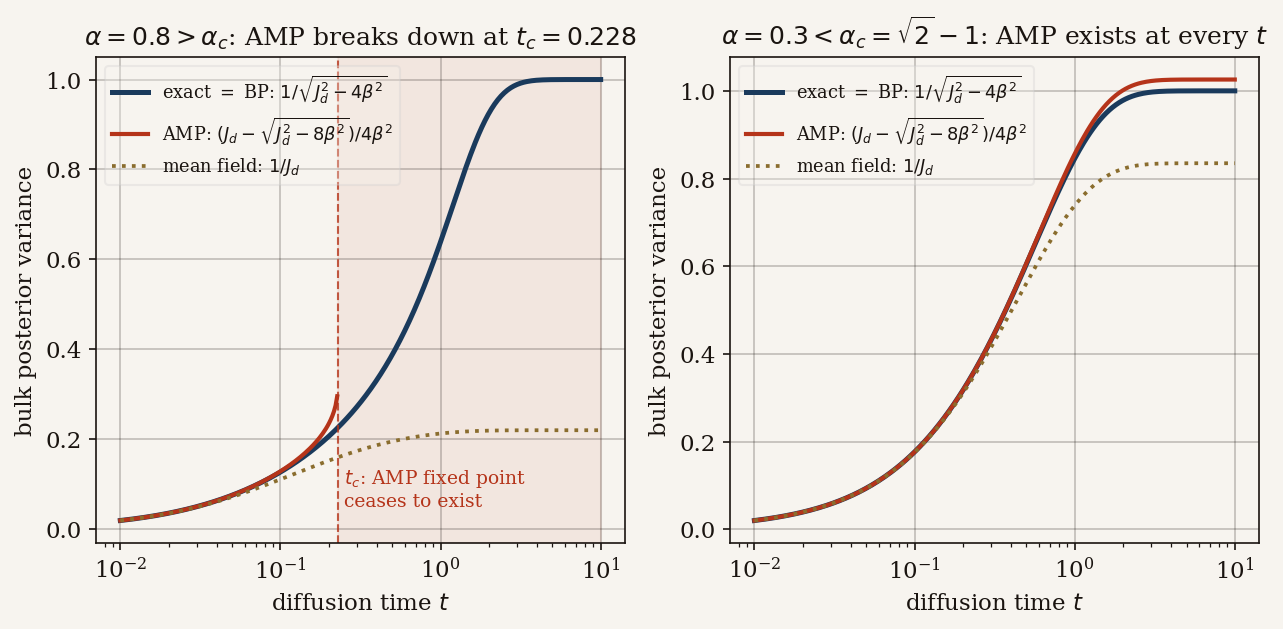

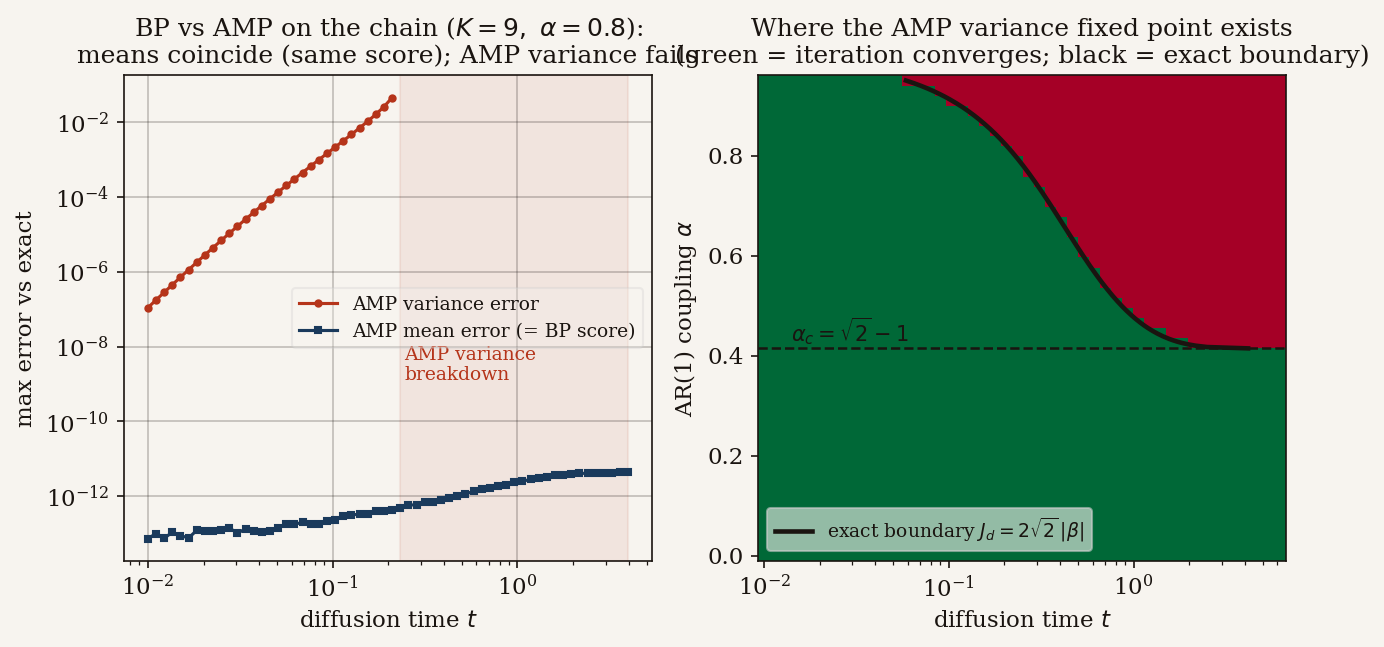

In [4]:
# The exact breakdown boundary: t_c(alpha) and alpha_c = sqrt(2)-1
print('alpha_c = sqrt(2) - 1 =', np.sqrt(2)-1)
for a in (0.3, 0.41, 0.42, 0.5, 0.7, 0.8, 0.95):
    tc = amp_critical_time(a)
    print(f'  alpha={a:<5} t_c = {"inf (never breaks down)" if np.isinf(tc) else f"{tc:.5f}"}')
display(Image(filename='figures/fig_bulk_variance.png'))
display(Image(filename='figures/fig_bp_vs_amp.png'))

## 3. Weak coupling: where AMP's variance error first appears

Expanding both closures in $\epsilon=\beta^2/J_d^2$:
they agree to $O(\epsilon)$, and
$$V_{\rm AMP}-V_{\rm exact}=\frac{2\beta^4}{J_d^5}+O(\beta^6)$$
— AMP always **over**estimates, starting at fourth order (`main.pdf` Th. 19).

In [5]:
print('ratio (V_amp - V_exact) / (2 beta^4/J_d^5)  ->  1 at weak coupling:')
for a in (0.2, 0.3, 0.4):
    for tt in (0.01, 0.02):
        ratio = ((amp_bulk_variance(a, tt) - bulk_variance_exact(a, tt))
                 / amp_weak_coupling_error(a, tt))
        print(f'   alpha={a} t={tt}:  ratio = {ratio:.4f}')

ratio (V_amp - V_exact) / (2 beta^4/J_d^5)  ->  1 at weak coupling:
   alpha=0.2 t=0.01:  ratio = 0.9979
   alpha=0.2 t=0.02:  ratio = 1.0007
   alpha=0.3 t=0.01:  ratio = 1.0005
   alpha=0.3 t=0.02:  ratio = 1.0016
   alpha=0.4 t=0.01:  ratio = 1.0009
   alpha=0.4 t=0.02:  ratio = 1.0034


## 4. Experiment A — local messages vs full sweeps

The radius-$r$ local estimator uses only $x_{k-r}..x_{k+r}$ (computed
*exactly* on the window: a block of a stationary AR(1) is a stationary AR(1)).
Both estimators are linear in $x$, so the RMS truncation error over
$x\sim P_t$ is a **deterministic closed-form number** — and its decay rate in
$r$ is exactly the posterior correlation decay $q(\alpha,t)$
(`main.pdf` Th. 20).

log-slope of the exact RMS truncation error vs the predicted log q:
   t=0.1  fitted slope = -1.34047   log q = -1.34045
   t=0.5  fitted slope = -0.55215   log q = -0.55146
   t=2.0  fitted slope = -0.24148   log q = -0.24107

radius = K-1 recovers the exact score:
   max |S_local(r=K-1) - S_full| = 8.881784197001252e-16


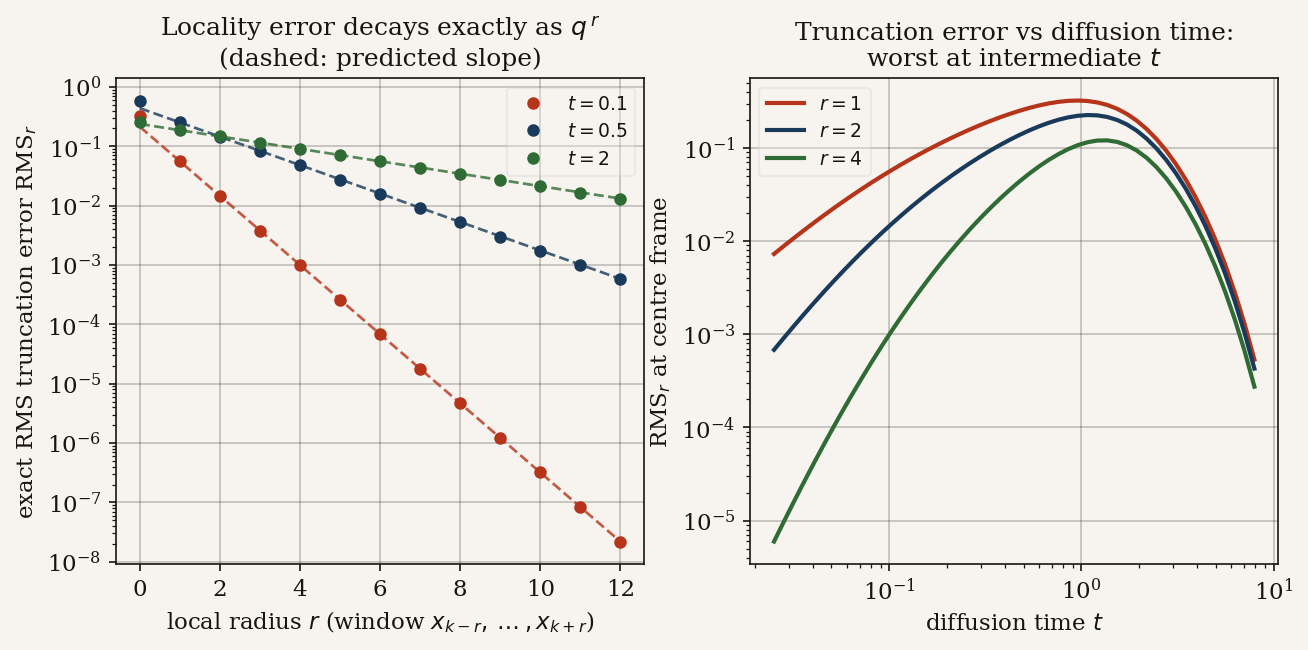

In [6]:
KA, aA = 121, 0.8
print('log-slope of the exact RMS truncation error vs the predicted log q:')
for tt in (0.1, 0.5, 2.0):
    rms = [rms_truncation_error(KA, aA, tt, KA//2, r) for r in range(0, 15)]
    rs = np.arange(2, 14)
    slope = np.polyfit(rs, np.log([rms[r] for r in rs]), 1)[0]
    print(f'   t={tt:<4} fitted slope = {slope:+.5f}   log q = {np.log(bulk_correlation_decay(aA, tt)):+.5f}')
print('\nradius = K-1 recovers the exact score:')
xA = np.random.default_rng(3).standard_normal(21)
S_full = joint_score_matrix(xA, 0.5, ar1_covariance(21, aA), aA)
print('   max |S_local(r=K-1) - S_full| =',
      np.max(np.abs(local_score(xA, 0.5, aA, 20) - S_full)))
display(Image(filename='figures/fig_local_vs_full.png'))

## 5. Experiment B — lifecycle of the precision matrix

$Q_t=\Sigma_t^{-1}$ is tridiagonal at $t=0$, the band fills for $t>0$ with the
**corrected** law
$(Q_t)_{i,i+d}=(-1)^{d-1}(2t)^{d-1}(Q_0^d)_{i,i+d}+O(t^d)$
(no $1/(d-1)!$ factor — `main.pdf` Remark 4 documents the correction), and
$Q_t\to I$ as $t\to\infty$ at rate $e^{-2t}$.  Eigenvectors are shared with
$\Sigma_0$ for every $t$ (near-Fourier modes); only eigenvalues flow.

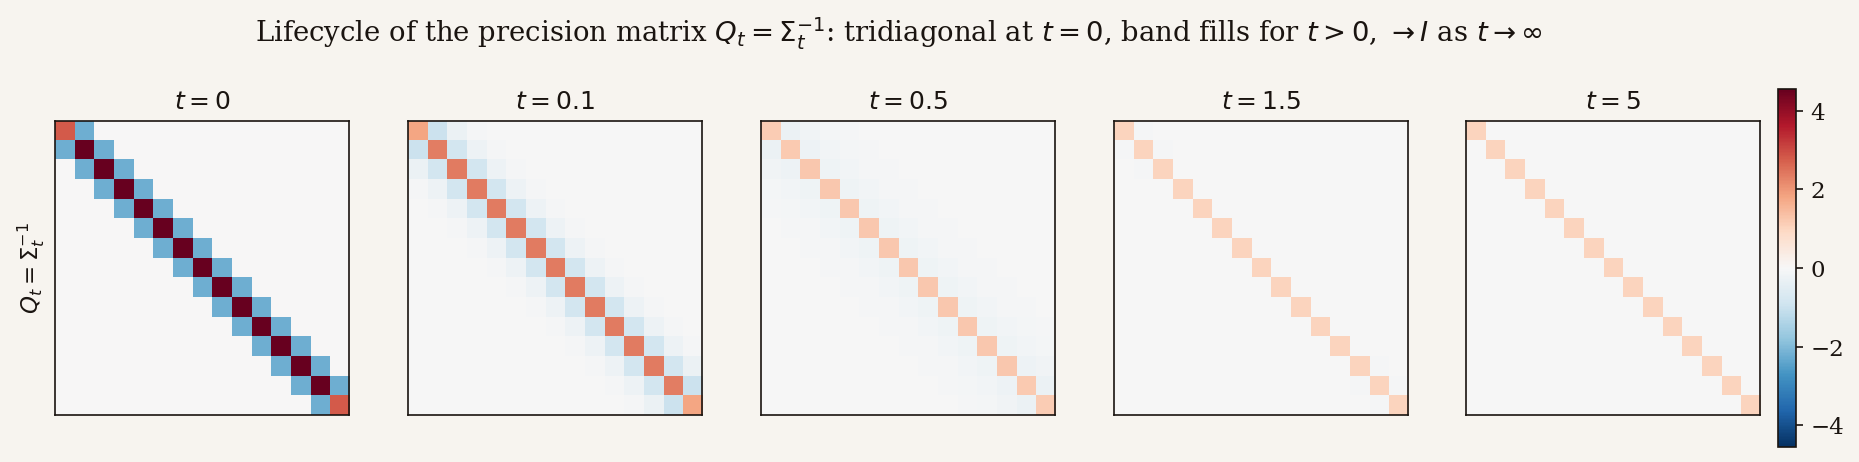

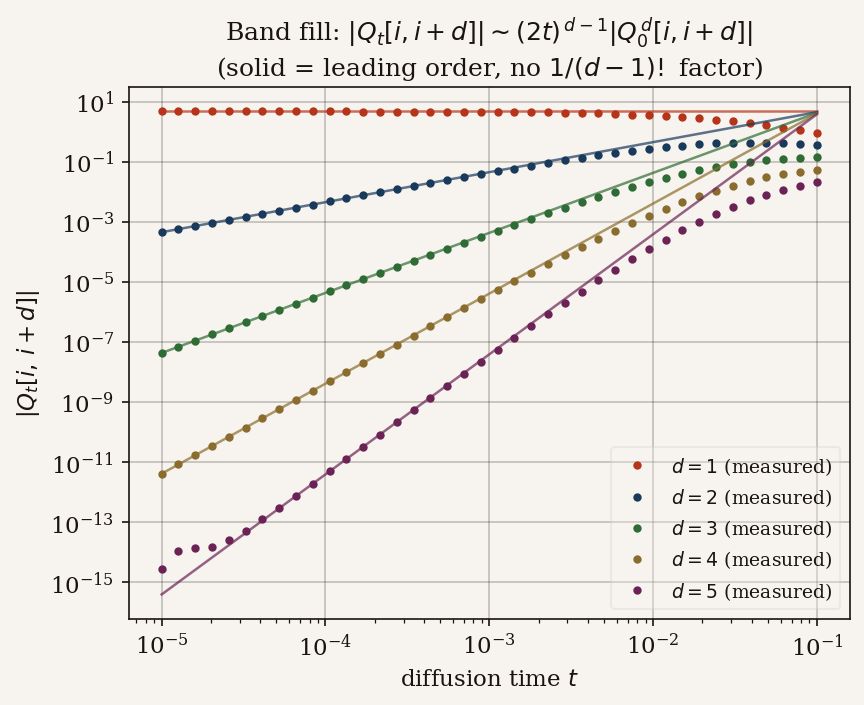

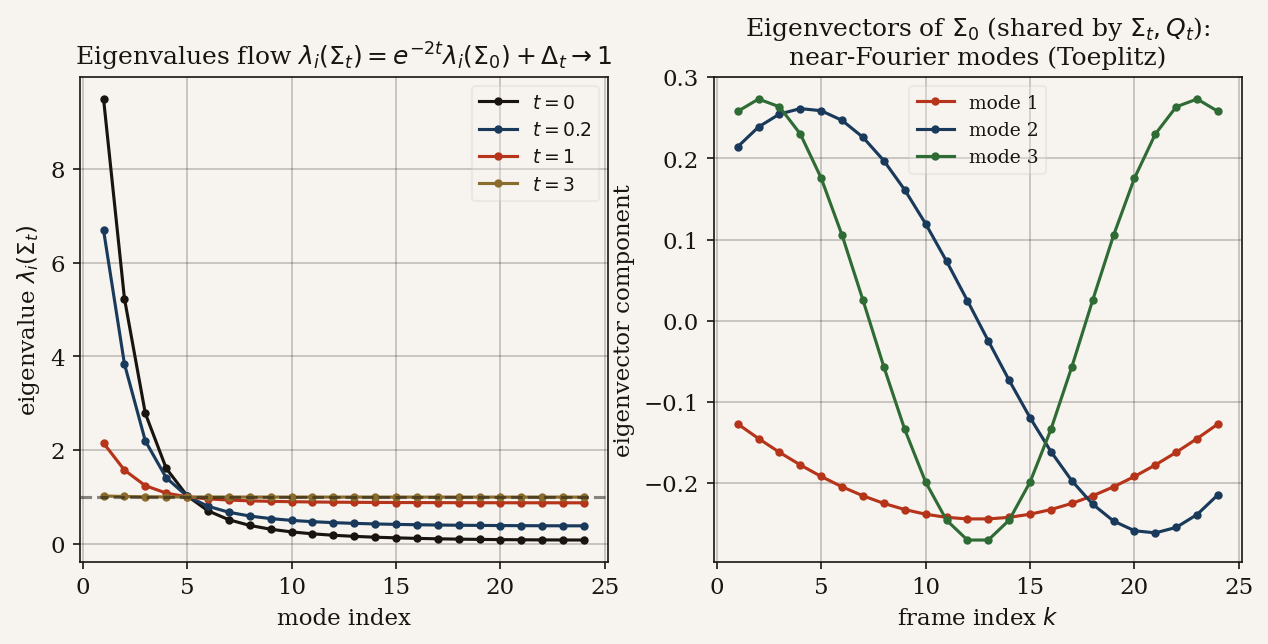

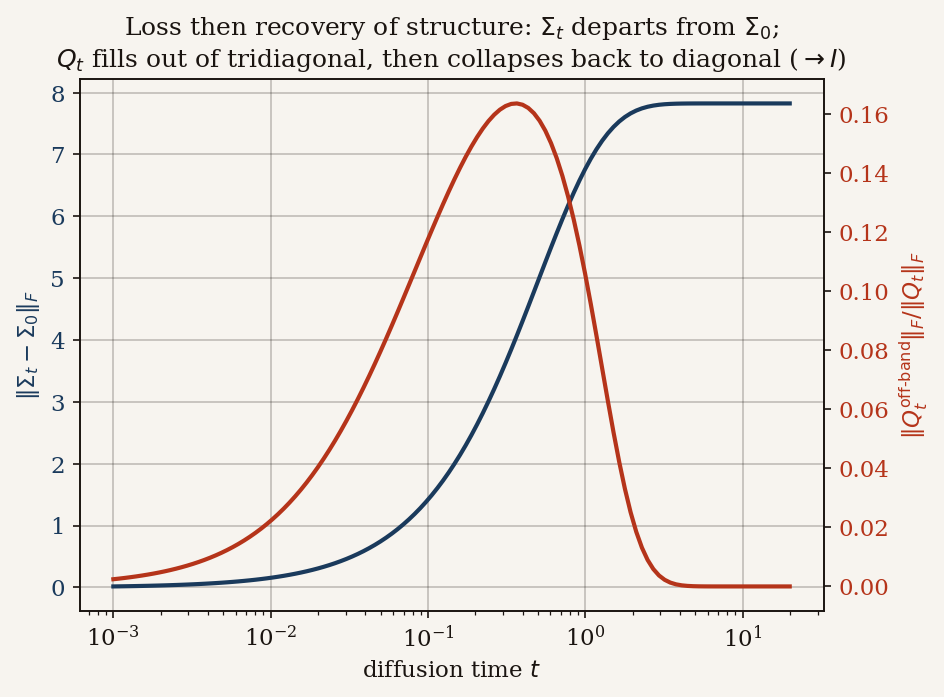

In [7]:
display(Image(filename='figures/fig_precision_lifecycle.png'))
display(Image(filename='figures/fig_band_fill.png'))
display(Image(filename='figures/fig_spectral.png'))
display(Image(filename='figures/fig_tridiag_loss.png'))

## 6. The full numerical audit — the gate

Every closed form quoted in `main.pdf` and in these notebooks, re-verified
end-to-end.  **A claim enters the text only if its check passes here.**

In [8]:
import numerical_audit
rc = numerical_audit.run_all()
assert rc == 0, 'AUDIT FAILED - do not trust the documents until fixed'

Gaussian BP / diffusion-score numerical audit  --  72 checks
[PASS] clean precision Q_0 (K=5, a=+0.30)                           err=2.22e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.30)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=+0.70)                           err=4.44e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.70)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=+0.90)                           err=7.99e-15  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.90)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=-0.50)                           err=1.23e-17  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=-0.50)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=9, a=+0.30)                           err=2.22e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=9, a=+0.30)                      err=0.00e+00  tol=0e+00
[PASS] clean precis

## Summary

* Bulk posterior: variance $1/\sqrt{J_d^2-4\beta^2}$, covariance $q^d\,V$ — verified to $10^{-11}$.
* BP fixed point exists for **every** $(\alpha,t)$; AMP's only for $J_d\ge2\sqrt2|\beta|$,
  i.e. below the exact breakdown time $t_c(\alpha)$; $\alpha_c=\sqrt2-1$.
* BP, AMP and mean field share the exact mean ⇒ the **same score**; the variance
  is where they differ ($+2\beta^4/J_d^5$ at weak coupling, no solution beyond $t_c$).
* Locality error decays exactly as $q^r$; the lifecycle of $Q_t$ is the same
  $q$-story seen in matrix form.
* Audit: **72/72**.